# Q1 Student Dataset
-----

installing the modules and libraries

In [1]:
# pip install pandas numpy matplotlib seaborn

Importing all necessary modules and libraries

In [2]:
import hashlib
import random
import numpy as np
import pandas as pd
from numpy import random
from matplotlib.sankey import Sankey

import seaborn as sns
import matplotlib.pyplot as plt


Function to create the watermark for evry plot i generate

In [3]:
def add_watermark(fig):
    fig.text(
        0.95, 0.95, "harshit.goyal",
        ha='right', va='top',
        fontsize=10, color='gray', alpha=0.7
    )

 Generating a personalised random seed

In [8]:
username = "harshit.goyal"
seed = int(hashlib.sha256(username.encode()).hexdigest(), 16) % (2**32)
# print(seed)

---

## Q1.0 Dataset Generation

Info about the dataset to be generated:
- Generate 10000 students records with the following attributes
  - Gender Male 65% Female 33% Other 2%
  - Major BTech 70% MS 20% PhD 10%
  - Program

     |Major | CSE | ECE | CHD | CND|
     |------|-----|-----|-----|-----|
     |BTech | 40% | 40% | 10% | 10% |
     |MS    | 30% | 30% | 20% | 20% |
     |PhD   | 25% | 25% | 25% | 25% |

  - GPA Normally dist with clipping to [4,10]
  
    |Major |GPA dist|
    |------|--------|
    |BTech | N(7.0,1.0)    |
    |MS    | N(8.0,0.7)    |
    |PhD   | N(8.3,0.5)    |

In [9]:
class StudentDataset:
        """Class to represent a student dataset with the required attributes and methods."""
        
        def __init__(self, num_students : int , seed : int):
                """Initialize the StudentDataset with the number of students and a seed."""
                self.num_students = num_students
                self.seed = seed
                np.random.seed(self.seed)
                random.seed(self.seed)
                self.assemble_dataframe()

        def get_full_dataframe(self) -> pd.DataFrame:
                """
                Returns the full student dataframe.
                """
                return self.data

        def generate_gender(self) -> list[str]:
                """
                Returns a random gender distribution for the students.
                """
                Male_percentage = 0.65; Female_percentage = 0.33; Other_percentage = 1 - Male_percentage - Female_percentage

                Male_count = int(Male_percentage*self.num_students)
                Female_count = int(Female_percentage*self.num_students)
                other_count = self.num_students - Male_count - Female_count

                gender_list = ['Male']*Male_count + ['Female']*Female_count + ['Other']*other_count
                random.shuffle(gender_list)
                return gender_list

        def generate_major(self) -> list[str]:
                """
                Returns a random major distribution for the students.
                """
                Btech_percentage = 0.70; MS_percentage = 0.20; PHD_percentage = 1 - Btech_percentage - MS_percentage

                Btech_count = int(Btech_percentage*self.num_students)
                MS_count = int(MS_percentage*self.num_students)
                PHD_count = self.num_students - Btech_count - MS_count

                major_list = ['Btech']*Btech_count + ['MS']*MS_count + ['PHD']*PHD_count
                random.shuffle(major_list)
                return major_list

        def generate_program(self, majors : list[str]) -> list[str]:
                """
                Argument: majors (list[str]) - List of student majors.
                Returns a random program distribution for the students.
                """
                Btech_count = majors.count('Btech'); MS_count = majors.count('MS'); PHD_count = majors.count('PHD')

                Btech_dist = {'CSE': 0.4,'ECE': 0.4,'CHD': 0.1,'CND': 0.1}
                MS_dist = {'CSE': 0.3,'ECE': 0.3,'CHD': 0.2,'CND': 0.2}
                PHD_dist = {'CSE': 0.25,'ECE': 0.25,'CHD': 0.25,'CND': 0.25}

                Btech_programs = self._generate_branches(Btech_count, Btech_dist)
                MS_programs = self._generate_branches(MS_count, MS_dist)
                PHD_programs = self._generate_branches(PHD_count, PHD_dist)
                
                programs_list = []
                i=j=k=0
                for major in majors:
                        if major == 'Btech':
                                programs_list.append(Btech_programs[i]);i += 1
                        elif major == 'MS':
                                programs_list.append(MS_programs[j]);j += 1
                        elif major == 'PHD':
                                programs_list.append(PHD_programs[k]);k += 1
                return programs_list

        def generate_gpa(self, majors : list[str]) -> list[float]:
                """
                Argument: majors (list[str]) - List of student majors.
                Returns random GPA values for the students based on their majors.(Normally distributed)
                """
                Btech_count = majors.count('Btech'); MS_count = majors.count('MS'); PHD_count = majors.count('PHD')

                lb = 4.0; ub = 10.0
                Btech_gpa = np.round(random.normal(7.0, 1.0, Btech_count), 2)
                MS_gpa = np.round(random.normal(8.0, 0.7, MS_count), 2)
                PHD_gpa = np.round(random.normal(8.3, 0.5, PHD_count), 2)

                gpa_list = []
                i=j=k=0
                for major in majors:
                        if major == 'Btech':
                                gpa_list.append(np.clip(Btech_gpa[i], lb, ub));i += 1
                        elif major == 'MS':
                                gpa_list.append(np.clip(MS_gpa[j], lb, ub));j += 1
                        elif major == 'PHD':
                                gpa_list.append(np.clip(PHD_gpa[k], lb, ub));k += 1
                return gpa_list

        def assemble_dataframe(self) -> None:
                """
                Assembles the final DataFrame.
                """
                genders = self.generate_gender()
                majors = self.generate_major()
                programs = self.generate_program(majors)
                gpa = self.generate_gpa(majors)
                data = pd.DataFrame({'Gender': genders,'Major': majors,'Program': programs,'GPA': gpa})
                self.data = data

        def _generate_branches(self, Count:int, Percent) -> list[str]:
                """
                Argument: Count (int) - Number of students in the major.
                Argument: Percent (dict) - Dictionary with program distribution percentages.
                Helper function to generate branches based on given percentages.
                """
                CSE_count = int(Count * Percent['CSE'])
                ECE_count = int(Count * Percent['ECE'])
                CHD_count = int(Count * Percent['CHD'])
                CND_count = Count - CSE_count - ECE_count - CHD_count

                branches_list = ['CSE']*CSE_count + ['ECE']*ECE_count + ['CHD']*CHD_count + ['CND']*CND_count
                random.shuffle(branches_list)
                return branches_list


Dataset = StudentDataset(num_students=10000, seed=seed)
data = Dataset.get_full_dataframe()
print(data.head())
data.to_csv('student_dataset.csv', index=False)

  Gender  Major Program   GPA
0   Male  Btech     ECE  7.00
1   Male  Btech     CHD  8.34
2   Male  Btech     ECE  8.25
3   Male     MS     ECE  6.91
4   Male     MS     CSE  7.94


---

## Q1.1 Dataset Analysis

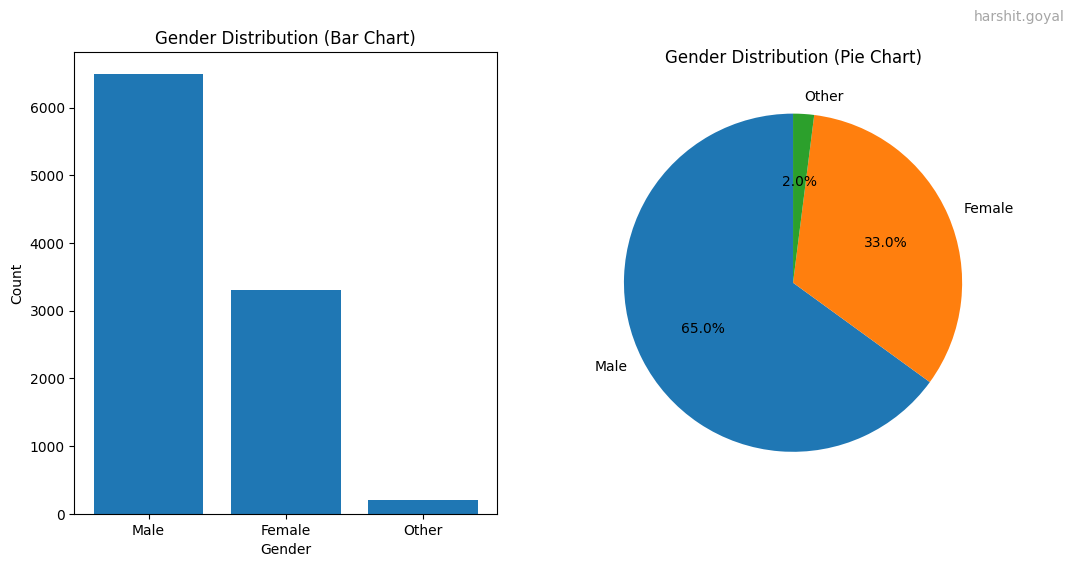

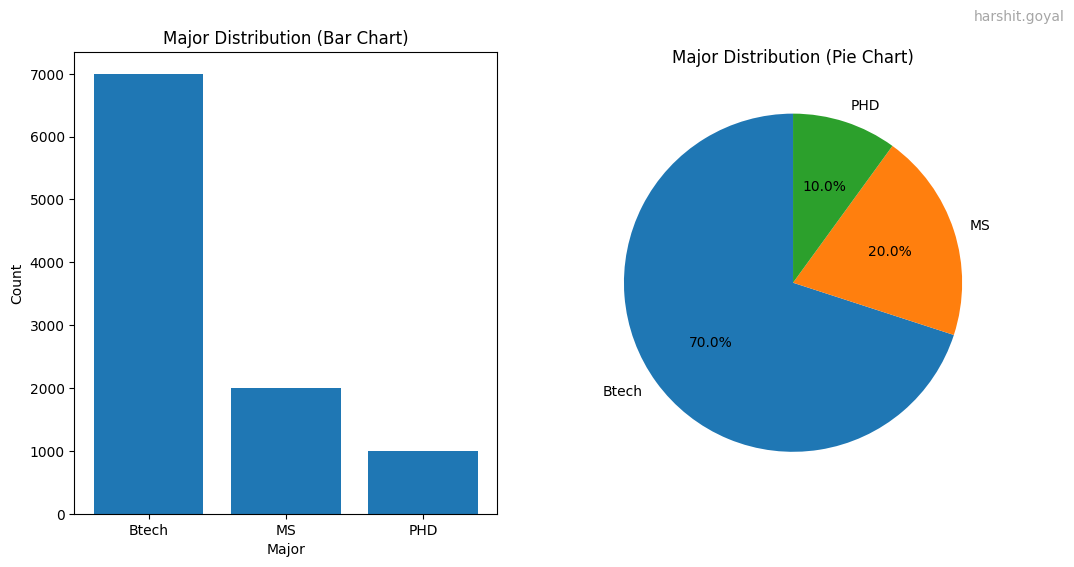

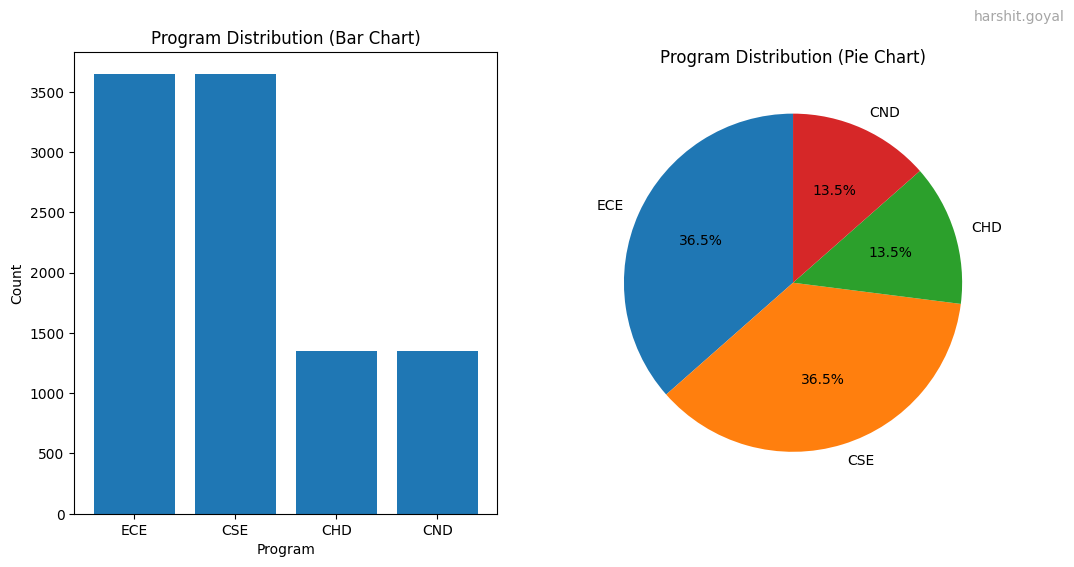

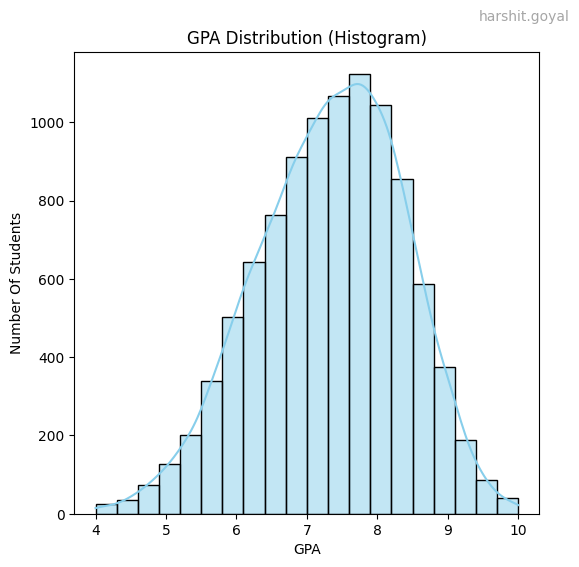

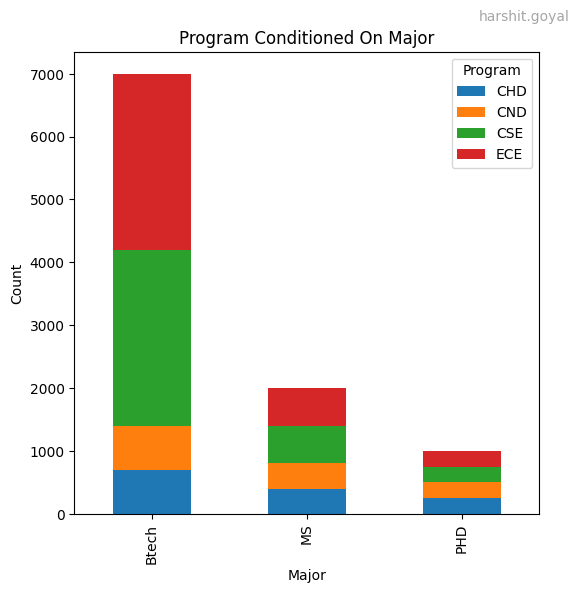

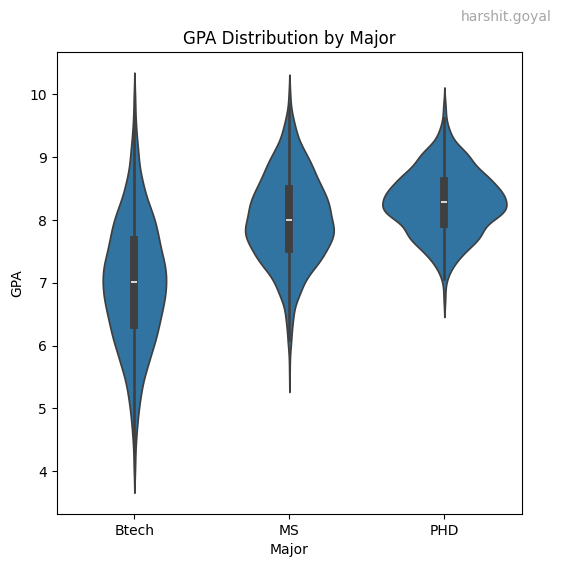

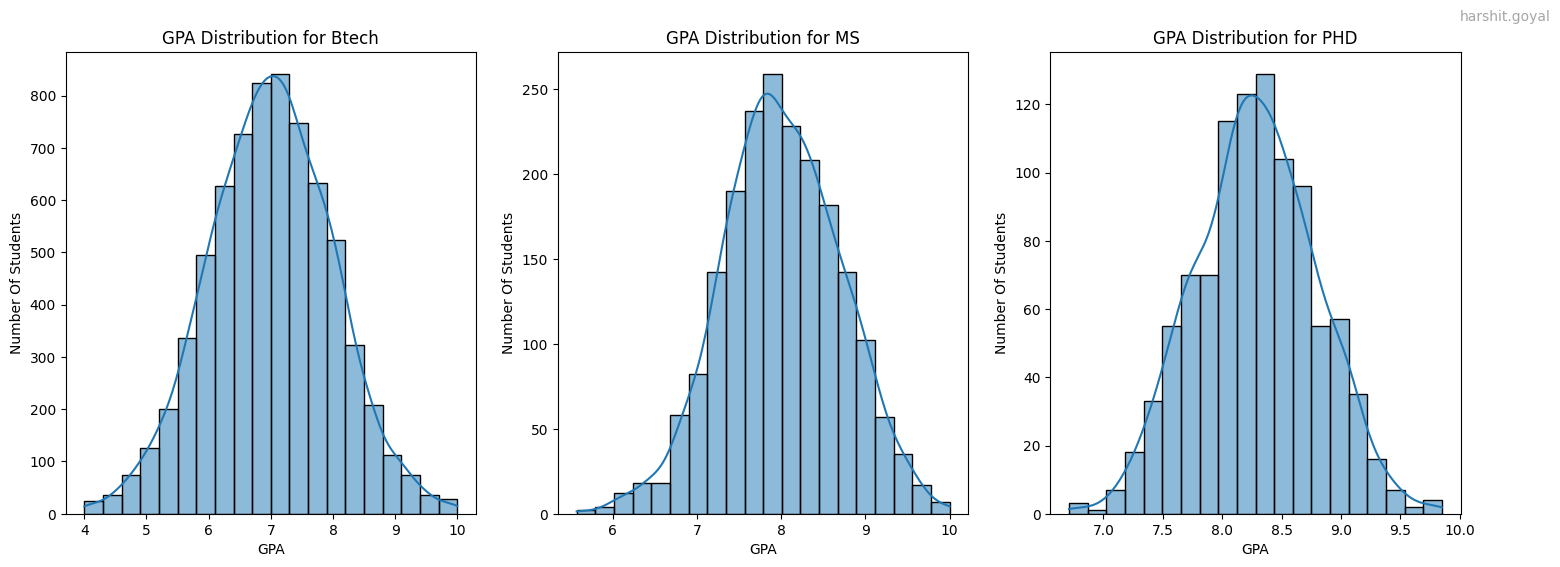

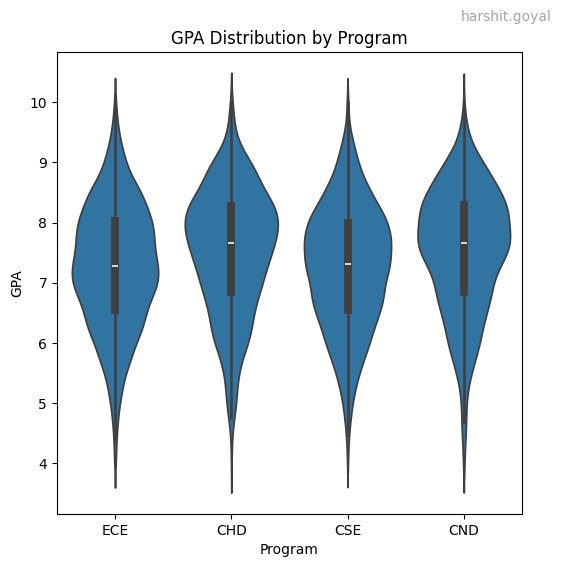

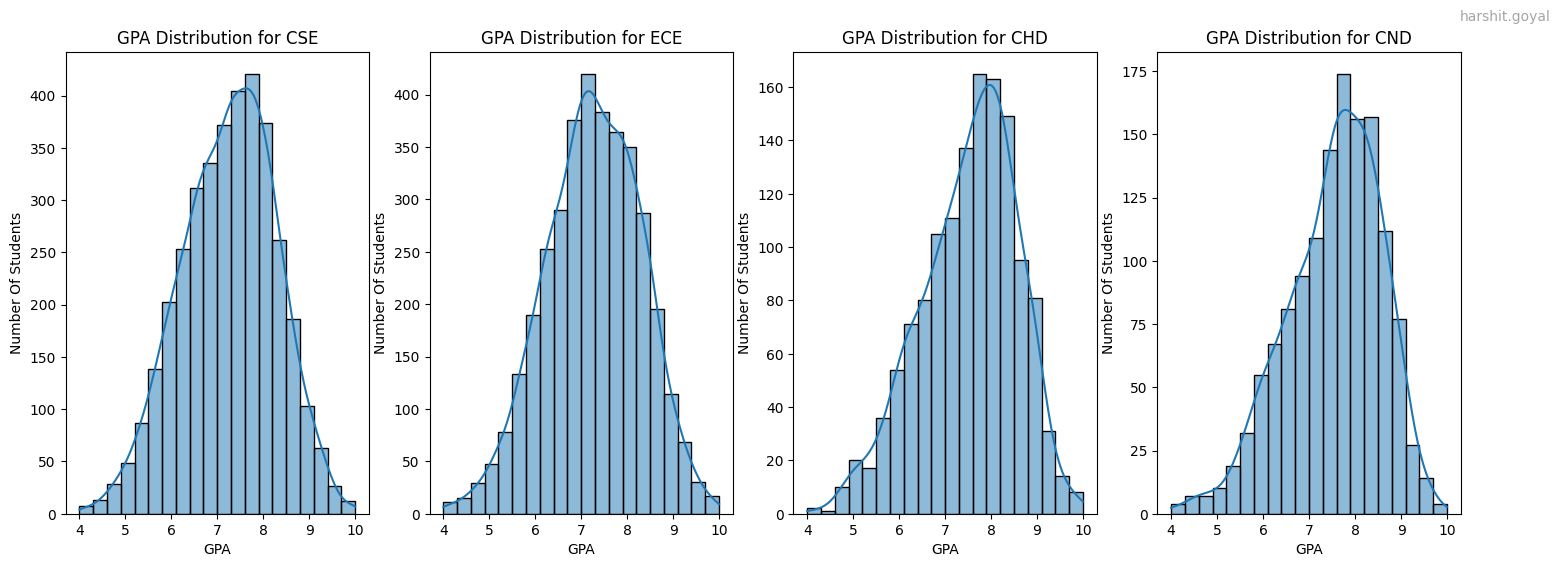

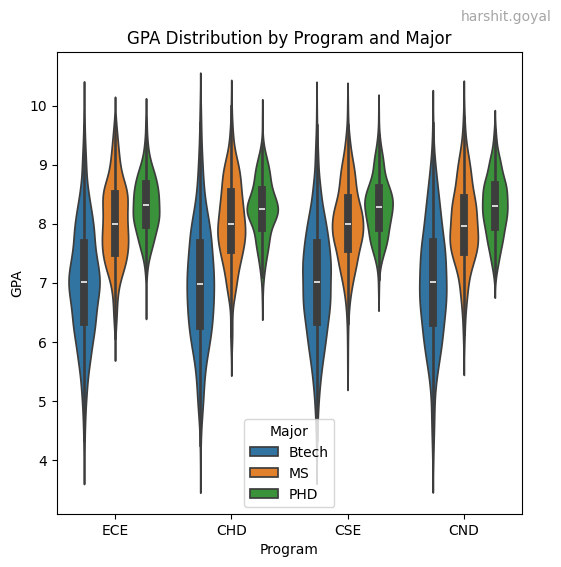

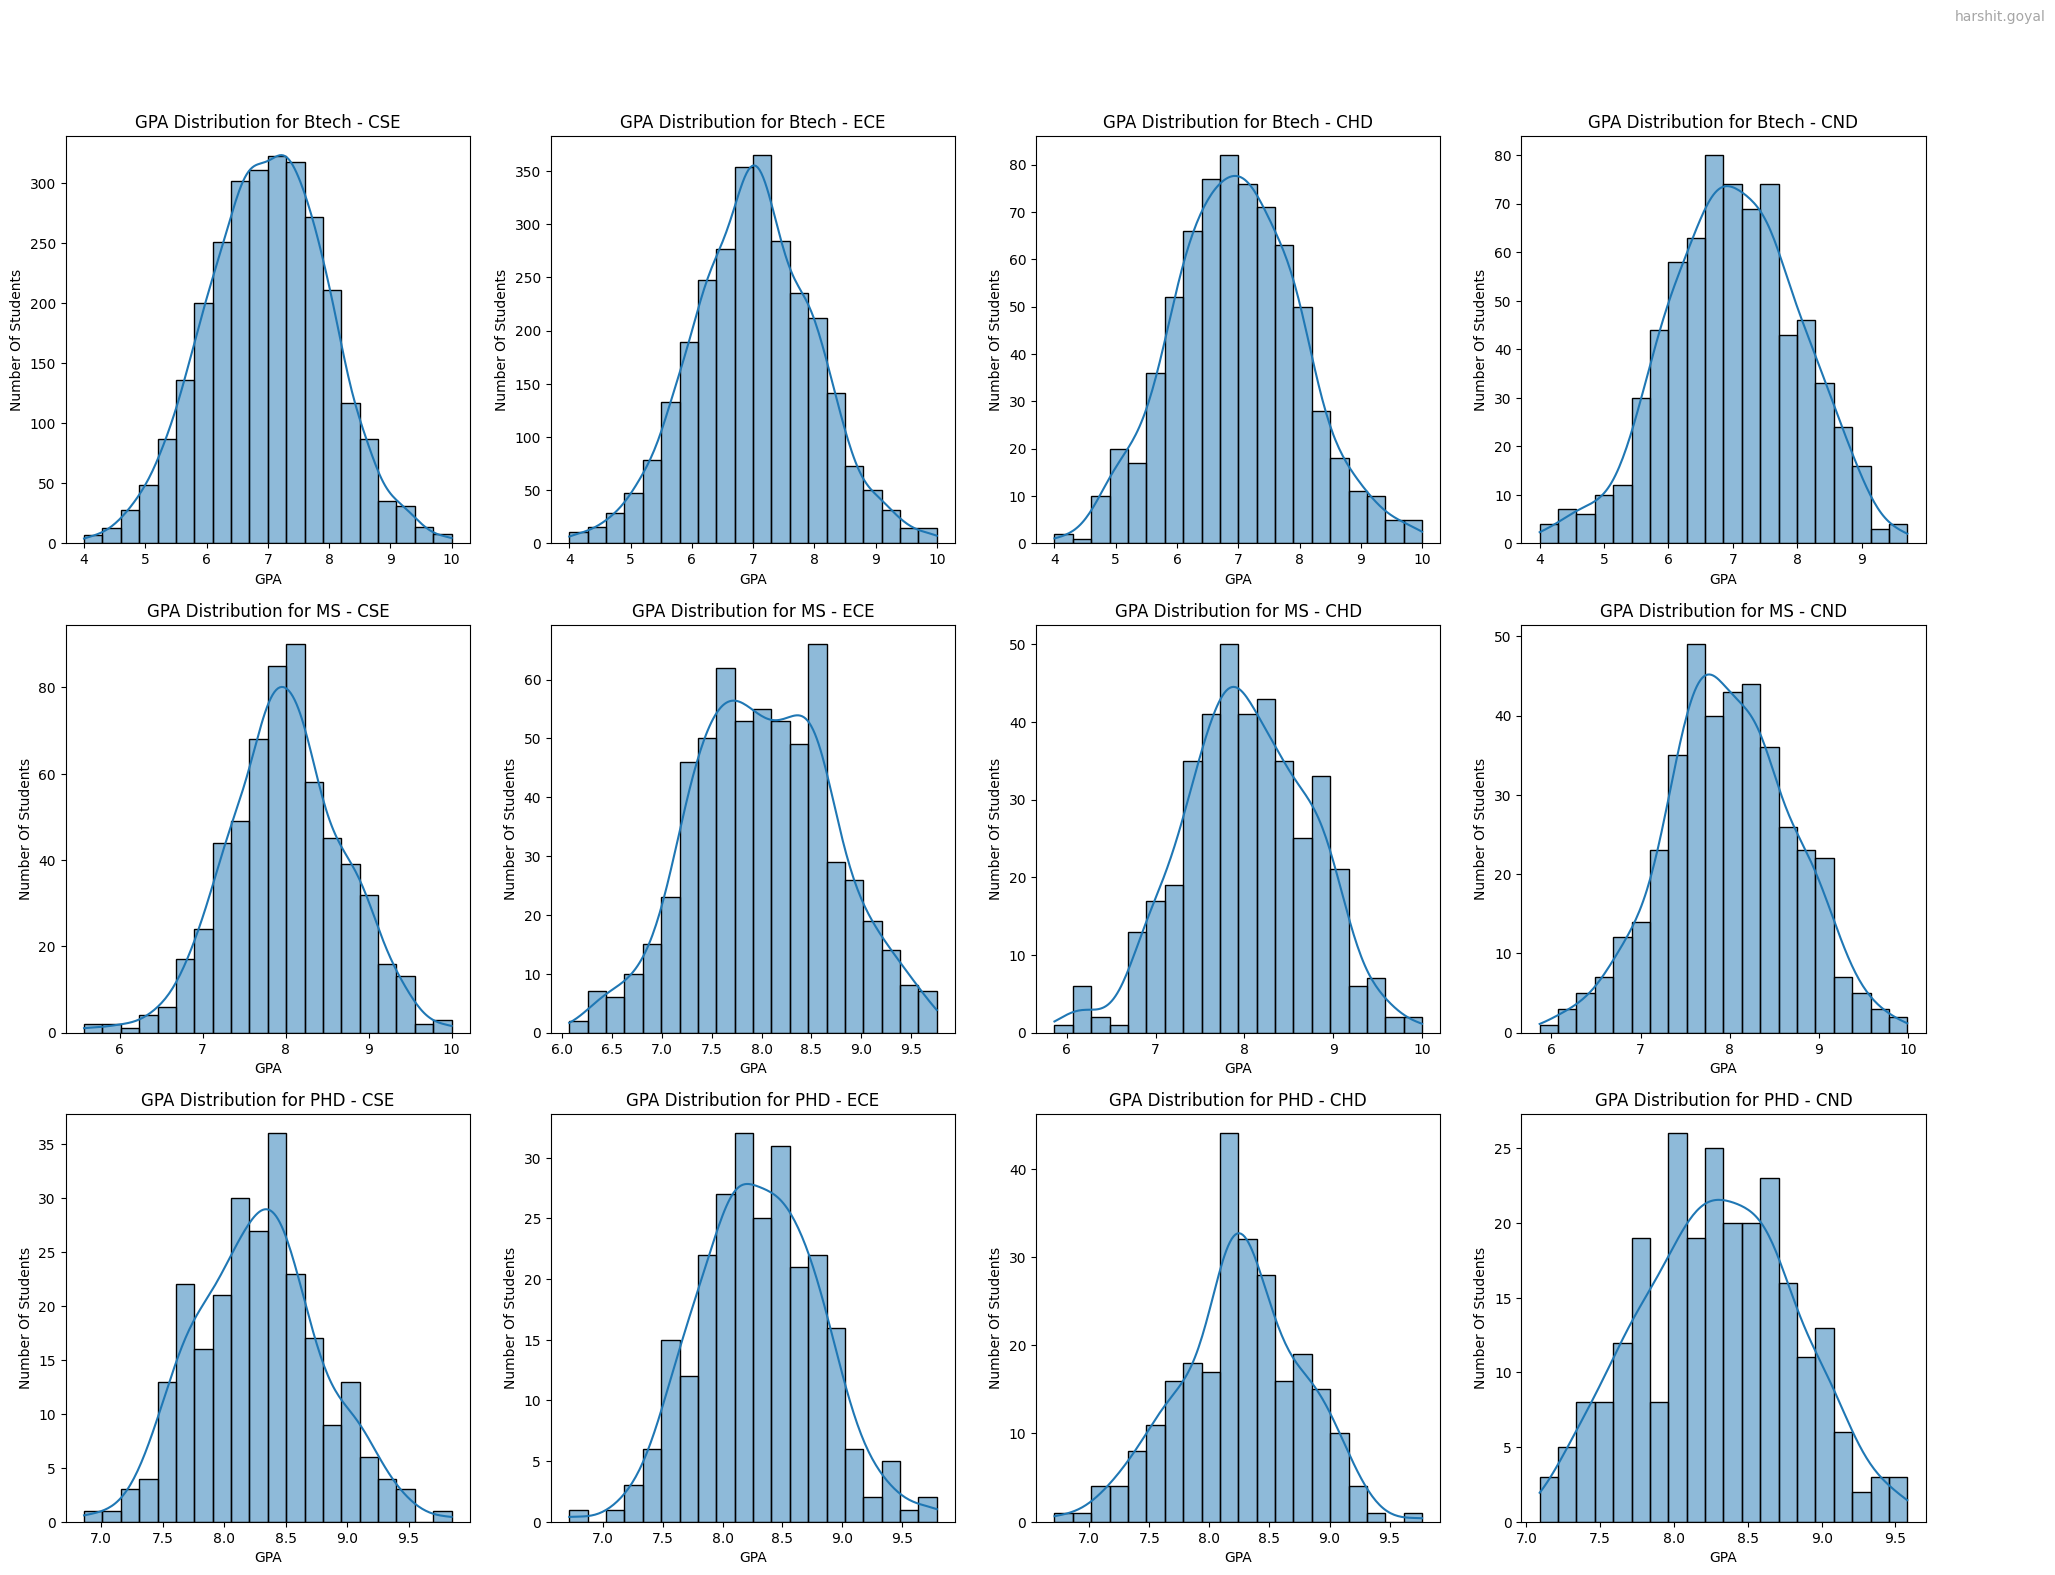

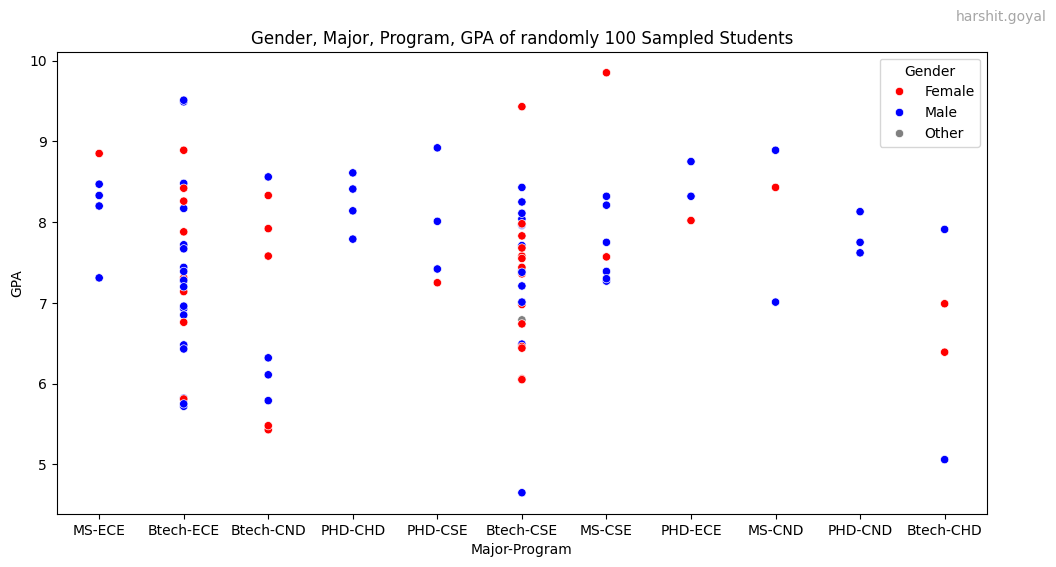

<Figure size 1200x600 with 0 Axes>

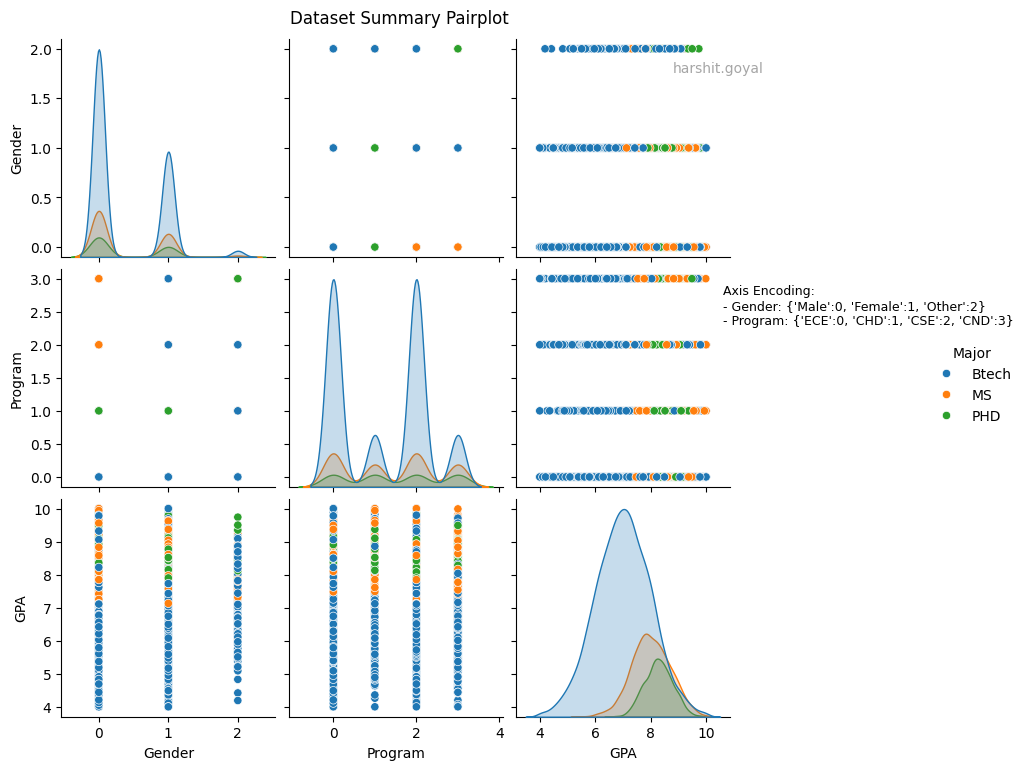

In [ ]:
class Visualizations():
    """Class for analyzing the student dataset by suitable visualization plots."""
    def __init__(self, data : pd.DataFrame):
        """
        Initialize the Analysis class and load the dataset.
        """
        self.data = data

    # a) Visualization
    def plot_gender_distribution(self) -> None:
        """
        Plots the gender distribution.
        """
        fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))
        add_watermark(fig)
        ax = ax.flatten()

        ax[0].bar(self.data["Gender"].value_counts().index, self.data["Gender"].value_counts().values)
        ax[0].set_title("Gender Distribution (Bar Chart)")
        ax[0].set_xlabel("Gender")
        ax[0].set_ylabel("Count")

        ax[1].pie(self.data["Gender"].value_counts(), labels=self.data["Gender"].value_counts().index, autopct='%1.1f%%', startangle=90)
        ax[1].set_title("Gender Distribution (Pie Chart)")
        ax[1].set_ylabel("")


    def plot_major_distribution(self) -> None:
        """
        Plots the major distribution.
        """
        fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))
        add_watermark(fig)
        ax = ax.flatten()

        ax[0].bar(self.data["Major"].value_counts().index, self.data["Major"].value_counts().values)
        ax[0].set_title("Major Distribution (Bar Chart)")
        ax[0].set_xlabel("Major")
        ax[0].set_ylabel("Count")

        ax[1].pie(self.data["Major"].value_counts(), labels=self.data["Major"].value_counts().index, autopct='%1.1f%%', startangle=90)
        ax[1].set_title("Major Distribution (Pie Chart)")
        ax[1].set_ylabel("")

    def plot_program_distribution(self) -> None:
        """
        Plots the program distribution.
        """
        fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))
        add_watermark(fig)
        ax = ax.flatten()

        ax[0].bar(self.data["Program"].value_counts().index, self.data["Program"].value_counts().values)
        ax[0].set_title("Program Distribution (Bar Chart)")
        ax[0].set_xlabel("Program")
        ax[0].set_ylabel("Count")

        ax[1].pie(self.data["Program"].value_counts(), labels=self.data["Program"].value_counts().index, autopct='%1.1f%%', startangle=90)
        ax[1].set_title("Program Distribution (Pie Chart)")
        ax[1].set_ylabel("")

    def plot_gpa_distribution(self, bins:int=20) -> None:
        """
        Plots the GPA distribution.
        """
        fig, ax = plt.subplots(figsize=(6, 6))
        add_watermark(fig)

        sns.histplot(self.data["GPA"], bins=bins, kde=True, color="skyblue", ax=ax)
        ax.set_title("GPA Distribution (Histogram)")
        ax.set_xlabel("GPA")
        ax.set_ylabel("Number Of Students")
        plt.show()

    def plot_program_by_major(self) -> None:
        """
        Plots the program distribution by major.
        """
        fig, ax = plt.subplots(figsize=(6, 6))
        add_watermark(fig)

        self.data.groupby(['Major', 'Program']).size().unstack().plot(kind='bar', stacked=True, ax=ax)
        ax.set_title("Program Conditioned On Major")
        ax.set_xlabel("Major")
        ax.set_ylabel("Count")
        ax.legend(title="Program")
        plt.show()

    def plot_gpa_by_major(self) -> None:
        """
        Plots the GPA distribution by major.
        """
        fig, ax = plt.subplots(figsize=(6, 6))
        add_watermark(fig)

        sns.violinplot(x="Major", y="GPA", data=self.data, ax=ax)
        ax.set_title("GPA Distribution by Major")
        ax.set_xlabel("Major")
        ax.set_ylabel("GPA")
        plt.show()


        fig,ax = plt.subplots(nrows=1,ncols=3,figsize=(18,6))
        add_watermark(fig)

        ax = ax.flatten()
        majors = ['Btech', 'MS', 'PHD']
        for i, major in enumerate(majors):
            sns.histplot(self.data[self.data["Major"] == major]["GPA"], bins=20, kde=True, ax=ax[i])
            ax[i].set_title(f"GPA Distribution for {major}")
            ax[i].set_xlabel("GPA")
            ax[i].set_ylabel("Number Of Students")

    def plot_gpa_by_program(self) -> None:
        """
        Plots the GPA distribution by program.
        """
        fig, ax = plt.subplots(figsize=(6, 6))
        add_watermark(fig)

        sns.violinplot(x="Program", y="GPA", data=self.data, ax=ax)
        ax.set_title("GPA Distribution by Program")
        ax.set_xlabel("Program")
        ax.set_ylabel("GPA")
        plt.show()

        fig, ax = plt.subplots(nrows=1,ncols=4,figsize=(18,6))
        add_watermark(fig)

        ax = ax.flatten()
        programs = ['CSE', 'ECE', 'CHD', 'CND']
        for i, program in enumerate(programs):
            sns.histplot(self.data[self.data["Program"] == program]["GPA"], bins=20, kde=True, ax=ax[i])
            ax[i].set_title(f"GPA Distribution for {program}")
            ax[i].set_xlabel("GPA")
            ax[i].set_ylabel("Number Of Students")

    def plot_gpa_by_program_and_major(self) -> None:
        """
        Plots the GPA distribution by program and major.
        """
        fig, ax = plt.subplots(figsize=(6, 6))
        add_watermark(fig)

        sns.violinplot(x="Program", y="GPA", hue="Major", data=self.data, ax=ax)
        ax.set_title("GPA Distribution by Program and Major")
        ax.set_xlabel("Program")
        ax.set_ylabel("GPA")
        plt.show()

        fig, ax = plt.subplots(nrows=3,ncols=4,figsize=(24,18))
        add_watermark(fig)

        ax = ax.flatten()

        majors = ['Btech', 'MS', 'PHD']
        programs = ['CSE', 'ECE', 'CHD', 'CND']
        for i, major in enumerate(majors):
            for j, program in enumerate(programs):
                sns.histplot(self.data[(self.data["Major"] == major) & (self.data["Program"] == program)]["GPA"], bins=20, kde=True, ax=ax[i*4 + j])
                ax[i*4 + j].set_title(f"GPA Distribution for {major} - {program}")
                ax[i*4 + j].set_xlabel("GPA")
                ax[i*4 + j].set_ylabel("Number Of Students")

    def plot_sampled_dataset(self) -> None:
        """
        Plots a sampled dataset of 100 students.
        """
        sampled = self.data.sample(n=100, random_state=seed)
        sampled["Major-Program"] = sampled["Major"] + "-" + sampled["Program"]
        fig, ax = plt.subplots(figsize=(12, 6))
        add_watermark(fig)

        sns.scatterplot(data=sampled,x="Major-Program",y="GPA",hue="Gender",palette={"Male":"blue", "Female":"red", "Other":"gray"})
        ax.set_title("Gender, Major, Program, GPA of randomly 100 Sampled Students")
        ax.set_xlabel("Major-Program")
        ax.set_ylabel("GPA")
        ax.legend(title="Gender")
        plt.show()

    def plot_entire_dataset_summary(self) -> None:
        """
        Plots the entire dataset summary in the form of a pairplot.
        """
        encoders = {}
        encoded_df = self.data.copy()
        major_labels = []

        for col in ['Gender', 'Major', 'Program']:
            codes, uniques = pd.factorize(encoded_df[col])
            encoded_df[col] = codes
            encoders[col] = {val: idx for idx, val in enumerate(uniques)}
            if col == 'Major':
                major_labels = uniques

        plt.figure(figsize=(12, 6))
        g = sns.pairplot(encoded_df, hue='Major', diag_kind="kde", palette="tab10")
        if g.legend is not None:
            for t, label in zip(g.legend.texts, major_labels):
                t.set_text(label)
            g.legend.set_title("Major")

        legend_parts = ["Axis Encoding:"]
        for col in ['Gender', 'Program']:
            mapping = encoders[col]
            map_str = ", ".join([f"'{k}':{v}" for k, v in mapping.items()])
            legend_parts.append(f"- {col.capitalize()}: {{{map_str}}}")
        legend_text = "\n".join(legend_parts)

        plt.gcf().text(0.9, 0.6, legend_text, fontsize=9)
        add_watermark(plt.gcf())
        g.fig.suptitle(f"Dataset Summary Pairplot", y=1.02)
        plt.show()


    def plot_all(self) -> None:
        """
        Plots all relevant visualizations.
        """
        self.plot_gender_distribution()
        self.plot_major_distribution()
        self.plot_program_distribution()
        self.plot_gpa_distribution()
        self.plot_program_by_major()
        self.plot_gpa_by_major()
        self.plot_gpa_by_program()
        self.plot_gpa_by_program_and_major()
        self.plot_sampled_dataset()
        self.plot_entire_dataset_summary()

v = Visualizations(data)
v.plot_all()

Mean is 7.329222 and Std dev is 1.0404076025836948
Major    Btech   MS  PHD
Program                 
CHD        700  400  250
CND        700  400  250
CSE       2800  600  250
ECE       2800  600  250


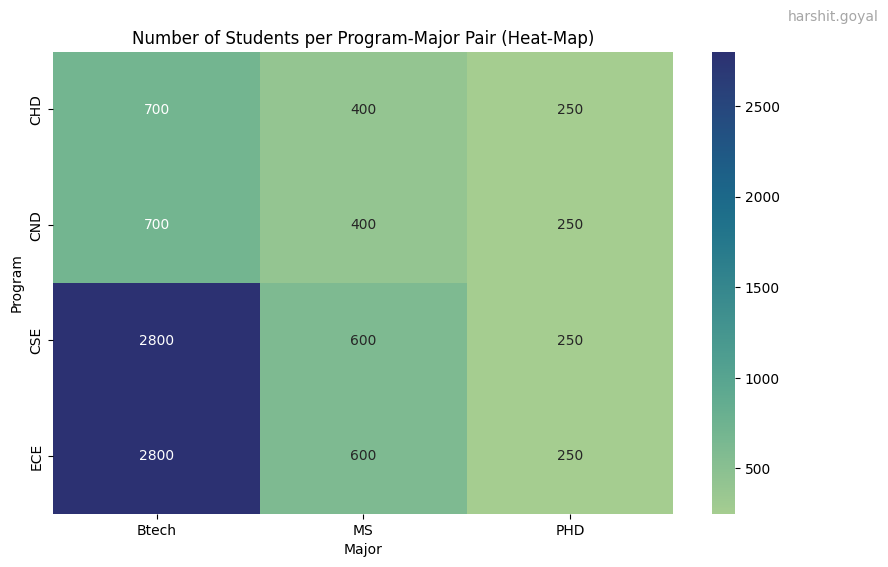

In [7]:
class Analysis():
    """Class for analyzing student data."""
    def __init__(self, data):
        """
        Initialize the Analysis class.
        """
        self.data = data

    def gpa_mean_std(self) -> tuple[float, float]:
        """
        Returns the mean and standard deviation of GPA.
        """
        mean_gpa = self.data["GPA"].mean()
        std_gpa = self.data["GPA"].std()
        return (mean_gpa, std_gpa)

    def count_students_per_program_major_pair(self) -> pd.DataFrame:
        """
        Returns the number of students in each program-major pair.
        """
        counts = self.data.groupby(['Program', 'Major']).size().unstack(fill_value=0)
        return counts 

    def visualize_students_per_program_major_pair(self, counts_df: pd.DataFrame) -> None:
        """
        Argument dataframe counts_df
        Visualize the number of students per program-major pair as a heatmap.
        """
        plt.figure(figsize=(10, 6))
        add_watermark(plt.gcf())
        sns.heatmap(counts_df, annot=True, fmt='d', cmap='crest')
        plt.title('Number of Students per Program-Major Pair (Heat-Map)')
        plt.xlabel('Major')
        plt.ylabel('Program')
        plt.show()

g = Analysis(data)
print(f"Mean is {g.gpa_mean_std()[0]} and Std dev is {g.gpa_mean_std()[1]}")
# Mean came out to be the weighted mean of the GPA according to the number of students in each major
# i.e Mean = (0.7*7)+(0.2*8)+(0.1*8.3) = 7.33 nearly equal to the mean calculated
# similar calculation can be done for the standard deviation

count = g.count_students_per_program_major_pair()
print(count)
g.visualize_students_per_program_major_pair(count)
# i have get the exactly same count which is initially given in my question

## Q 1.2 Simple vs Stratified Sampling

In [8]:
class SimpleStratifiedLearning():
    """Class for comparing simple random sampling and stratified sampling."""
    def __init__(self, data):
        """Initialize the SimpleStratifiedLearning class."""
        self.data = data

    def get_gpa_mean_std_random(self, n: int = 500, repeats: int = 50) -> tuple[float, float]:
        """Calculate mean and standard deviation of GPA using random sampling."""
        gpa_sum=0; std_sum=0
        for it in range(repeats):
            sample = self.data.sample(n=n, random_state=seed+it)
            mean_gpa = sample['GPA'].mean()
            std_gpa = sample['GPA'].std()
            gpa_sum += mean_gpa
            std_sum += std_gpa

        return (gpa_sum / repeats, std_sum / repeats)

    def get_gpa_mean_std_stratified(self, n: int = 500, repeats: int = 50) -> tuple[float, float]:
        """Calculate mean and standard deviation of GPA using stratified sampling."""
        gpa_sum=0; std_sum=0
        for it in range(repeats):
            sample = self.data.groupby('Major').apply(lambda x: x.sample(n=n, random_state=seed+it), include_groups=False)
            mean_gpa = sample['GPA'].mean()
            std_gpa = sample['GPA'].std()
            gpa_sum += mean_gpa
            std_sum += std_gpa

        return (gpa_sum / repeats, std_sum / repeats)

ssl = SimpleStratifiedLearning(data)
print("Random Method")
print(f" Mean is {ssl.get_gpa_mean_std_random()[0]} and st dev is {ssl.get_gpa_mean_std_random()[1]}")
print("Stratified Method")
print(f" Mean is {ssl.get_gpa_mean_std_stratified()[0]} and st dev is {ssl.get_gpa_mean_std_stratified()[1]}")

# Stratified Method has less standard deviation compared to Random Method
# This is because stratified sampling ensures that each subgroup (stratum) is adequately represented in the sample,
# leading to more reliable estimates.

Random Method
 Mean is 7.3245652 and st dev is 1.0345384668140678
Stratified Method
 Mean is 7.757481200000001 and st dev is 0.9487784244301207


## Q1.3 Gender-Balanced Cohort

 --- Reporting Gender Counts for Uniform Random Sampling ---
Repeat 1: {'Other': 103, 'Male': 102, 'Female': 95}
Repeat 2: {'Female': 112, 'Other': 102, 'Male': 86}
Repeat 3: {'Female': 113, 'Other': 102, 'Male': 85}
Repeat 4: {'Male': 118, 'Other': 106, 'Female': 76}
Repeat 5: {'Other': 113, 'Female': 99, 'Male': 88}
 --- Reporting Gender Counts for Balanced Sampling ---
Repeat 1: {'Female': 100, 'Male': 100, 'Other': 100}
Repeat 2: {'Female': 100, 'Male': 100, 'Other': 100}
Repeat 3: {'Female': 100, 'Male': 100, 'Other': 100}
Repeat 4: {'Female': 100, 'Male': 100, 'Other': 100}
Repeat 5: {'Female': 100, 'Male': 100, 'Other': 100}

--- Calculating Average Max Relative Difference ---
Sample Size: 300, Average Max Relative Difference: 0.0510
Sample Size: 600, Average Max Relative Difference: 0.0325
Sample Size: 900, Average Max Relative Difference: 0.0404
Sample Size: 1200, Average Max Relative Difference: 0.0287
Sample Size: 1500, Average Max Relative Difference: 0.0241


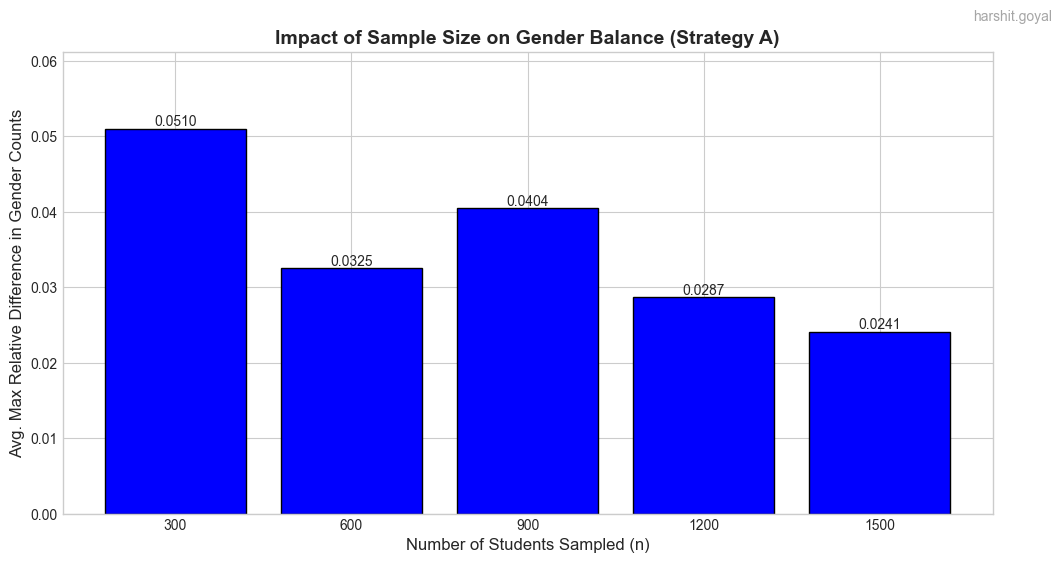

In [9]:

class GenderSampler():
    """Class for sampling students in a gender-balanced way."""

    def __init__(self, data):
        """
        Initialize the GenderSampler class.
        """
        self.data = data
        self.Genders = self.data['Gender'].unique()
        # Pre-calculating groups can speed up repeated sampling
        self.GenderGroups = {gender: group for gender, group in self.data.groupby('Gender')}

    def get_gender_balanced_counts(self, n: int = 300, repeats: int = 5) -> list[dict[str, int]]:
        """
        Argument n: int and repeats: int
        Returns counts of each gender in the balanced sample.
        """
        all_counts = []
        if n % len(self.Genders) != 0:
            raise ValueError(f"Sample size 'n' ({n}) must be divisible by the number of genders ({len(self.Genders)}).")

        samples_per_gender = n // len(self.Genders)

        for i in range(repeats):
            balanced_sample = self.data.groupby('Gender').sample(
                n=samples_per_gender, replace=True
            )
            
            gender_counts = balanced_sample['Gender'].value_counts().to_dict()
            all_counts.append(gender_counts)
            
        return all_counts

    def sample_gender_uniform_random(self, n: int = 300, repeats: int = 5) -> list[dict[str, int]]:
        """
        Argument n: int and repeats: int
        Returns counts of each gender in the uniform random sample.
        """
        all_counts = []
        
        for i in range(repeats):
            sampled_indices = []
            for _ in range(n):
                chosen_gender = random.choice(self.Genders)
                random_student = self.GenderGroups[chosen_gender].sample(n=1)
                sampled_indices.append(random_student.index[0])
            
            sampled_df = self.data.loc[sampled_indices]
            gender_counts = sampled_df['Gender'].value_counts().to_dict()
            all_counts.append(gender_counts)
            
        return all_counts

    def plot_avg_max_gender_diff_vs_sample_size(self, sample_sizes: list[int], repeats: int = 10) -> None:
        """
        Argument sample_sizes: list[int] and repeats: int
        Plot the average maximum relative difference in gender proportions.
        """
        print(f"\n--- Calculating Average Max Relative Difference ---")
        avg_diffs = []

        for size in sample_sizes:
            relative_diffs_for_size = []
            for _ in range(repeats):
                indices = [
                    self.GenderGroups[random.choice(self.Genders)].sample(n=1).index[0]
                    for _ in range(size)
                ]
                sampled_df = self.data.loc[indices]
                
                counts = sampled_df['Gender'].value_counts()
                proportions = counts / size
                proportions = proportions.reindex(self.Genders, fill_value=0)

                max_rel_diff = proportions.max() - proportions.min()
                relative_diffs_for_size.append(max_rel_diff)
            
            avg_diff = np.mean(relative_diffs_for_size)
            avg_diffs.append(avg_diff)
            print(f"Sample Size: {size}, Average Max Relative Difference: {avg_diff:.4f}")

        plt.style.use('seaborn-v0_8-whitegrid')
        plt.figure(figsize=(12, 6))
        add_watermark(plt.gcf())
        bars = plt.bar([str(s) for s in sample_sizes], avg_diffs, color='blue', edgecolor='black')
        
        plt.xlabel("Number of Students Sampled (n)", fontsize=12)
        plt.ylabel("Avg. Max Relative Difference in Gender Counts", fontsize=12)
        plt.title("Impact of Sample Size on Gender Balance (Strategy A)", fontsize=14, weight='bold')
        plt.ylim(0, max(avg_diffs) * 1.2)
        
        for bar in bars:
            yval = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval:.4f}', va='bottom', ha='center') 

        plt.show()
    

sampler = GenderSampler(data)
balanced_counts = sampler.get_gender_balanced_counts(n=300,repeats=5)
strategy_a_counts = sampler.sample_gender_uniform_random(n=300, repeats=5)

print(" --- Reporting Gender Counts for Uniform Random Sampling ---")
for i, counts in enumerate(strategy_a_counts):
    print(f"Repeat {i+1}: {counts}")

print(" --- Reporting Gender Counts for Balanced Sampling ---")
for i, counts in enumerate(balanced_counts):
    print(f"Repeat {i+1}: {counts}")

sample_sizes_to_test = [300, 600, 900, 1200, 1500]
sampler.plot_avg_max_gender_diff_vs_sample_size(sample_sizes=sample_sizes_to_test, repeats=10)

    

## Q 1.4 GPA-Uniform Cohort

Bin 1 [(3.999, 4.6]]: Sampled 10 from 63 (WITHOUT replacement)
Bin 2 [(4.6, 5.2]]: Sampled 10 from 206 (WITHOUT replacement)
Bin 3 [(5.2, 5.8]]: Sampled 10 from 543 (WITHOUT replacement)
Bin 4 [(5.8, 6.4]]: Sampled 10 from 1151 (WITHOUT replacement)
Bin 5 [(6.4, 7.0]]: Sampled 10 from 1690 (WITHOUT replacement)
Bin 6 [(7.0, 7.6]]: Sampled 10 from 2094 (WITHOUT replacement)
Bin 7 [(7.6, 8.2]]: Sampled 10 from 2154 (WITHOUT replacement)
Bin 8 [(8.2, 8.8]]: Sampled 10 from 1419 (WITHOUT replacement)
Bin 9 [(8.8, 9.4]]: Sampled 10 from 554 (WITHOUT replacement)
Bin 10 [(9.4, 10.0]]: Sampled 10 from 126 (WITHOUT replacement)

Total sampled: 100 students
Sampling strategy: Mixed (with and without replacement as needed per bin)


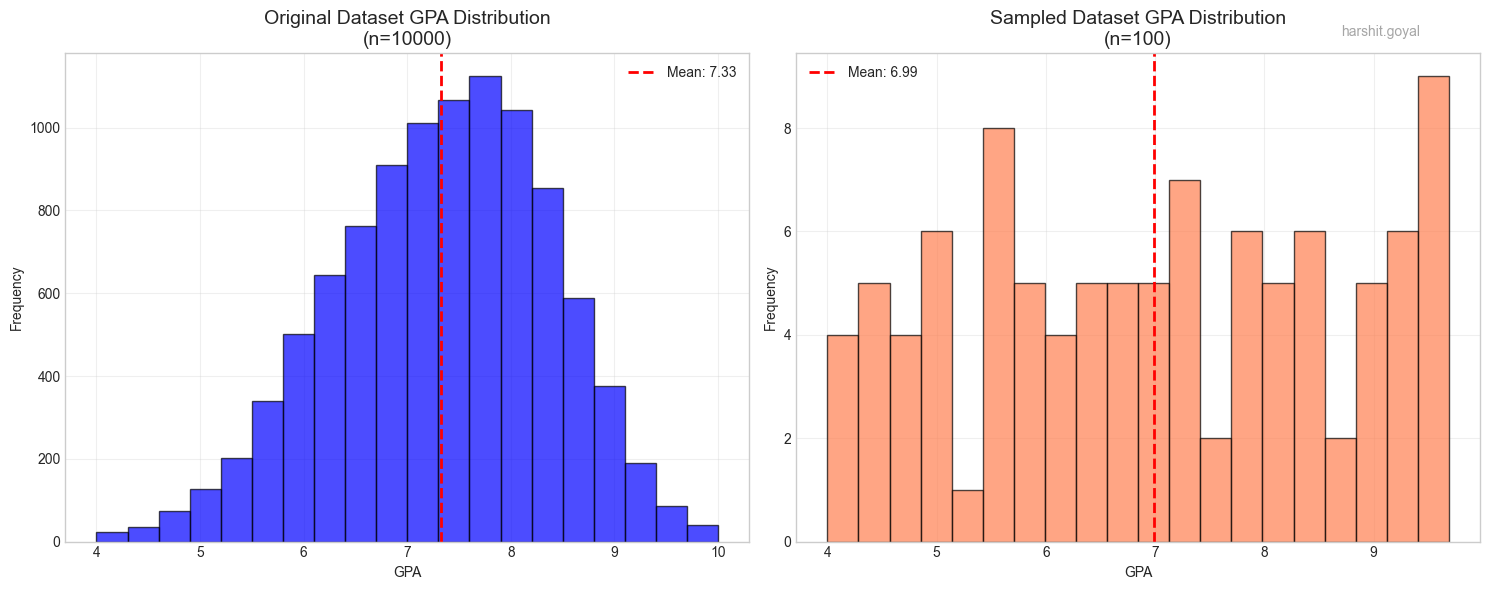


--------------------------------------------------
DISTRIBUTION COMPARISON
--------------------------------------------------
Metric               Original        Sampled         Difference     
-----------------------------------------------------------------
Mean GPA             7.329           6.991           0.339          
Std Dev              1.040           1.683           0.643          
Min GPA              4.000           4.000           0.000          
Max GPA              10.000          9.690           0.310          

--------------------------------------------------
UNIFORM DISTRIBUTION ANALYSIS
--------------------------------------------------
Expected samples per bin (uniform): 10.0
Actual distribution across bins:
  Bin 1: 10 samples (deviation: +0.0)
  Bin 2: 10 samples (deviation: +0.0)
  Bin 3: 9 samples (deviation: -1.0)
  Bin 4: 10 samples (deviation: +0.0)
  Bin 5: 11 samples (deviation: +1.0)
  Bin 6: 10 samples (deviation: +0.0)
  Bin 7: 10 samples (deviati

In [10]:
class GPASampler():
    """Class for sampling students to achieve a uniform GPA distribution."""
    def __init__(self, data: pd.DataFrame):
        """
        Initialize the GPASampler with the student data.
        """
        self.data = data

    def sample_gpa_uniform(self, n: int = 100, bins: int = 10) -> pd.DataFrame:
        """
        Argument n: int and bins: int
        Returns a DataFrame of students sampled uniformly across GPA bins.
        """
        gpa_min = self.data['GPA'].min()
        gpa_max = self.data['GPA'].max()
        bin_edges = np.linspace(gpa_min, gpa_max, bins + 1)
        
        self.data['GPA_bin'] = pd.cut(self.data['GPA'], bins=bin_edges, include_lowest=True)
        
        samples_per_bin = n // bins
        remaining_samples = n % bins
        
        sampled_students = []
        
        for i, bin_label in enumerate(self.data['GPA_bin'].cat.categories):
            bin_students = self.data[self.data['GPA_bin'] == bin_label]
            
            if len(bin_students) == 0:
                continue
                
            target_samples = samples_per_bin
            if i < remaining_samples:  # Distribute remaining samples to first few bins
                target_samples += 1
            
            if len(bin_students) < target_samples:
                sampled_bin = bin_students.sample(n=target_samples, replace=True, random_state=42)
                print(f"Bin {i+1} [{bin_label}]: Sampled {target_samples} from {len(bin_students)} (WITH replacement)")
            else:
                sampled_bin = bin_students.sample(n=target_samples, replace=False, random_state=42)
                print(f"Bin {i+1} [{bin_label}]: Sampled {target_samples} from {len(bin_students)} (WITHOUT replacement)")
            
            sampled_students.append(sampled_bin)
        
        result_df = pd.concat(sampled_students, ignore_index=True)
        result_df = result_df.drop('GPA_bin', axis=1)
        
        print(f"\nTotal sampled: {len(result_df)} students")
        print(f"Sampling strategy: Mixed (with and without replacement as needed per bin)")
        
        return result_df
    
    def plot_gpa_histogram_comparison(self, sampled_df: pd.DataFrame) -> None:
        """
        Plot histograms of the original and sampled GPA distributions.
        """
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
        add_watermark(fig)
        
        ax1.hist(self.data['GPA'], bins=20, alpha=0.7, color='blue', edgecolor='black')
        ax1.set_title(f'Original Dataset GPA Distribution\n(n={len(self.data)})', fontsize=14)
        ax1.set_xlabel('GPA')
        ax1.set_ylabel('Frequency')
        ax1.grid(True, alpha=0.3)
        
        orig_mean = self.data['GPA'].mean()
        orig_std = self.data['GPA'].std()
        ax1.axvline(orig_mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {orig_mean:.2f}')
        ax1.legend()
        
        ax2.hist(sampled_df['GPA'], bins=20, alpha=0.7, color='coral', edgecolor='black')
        ax2.set_title(f'Sampled Dataset GPA Distribution\n(n={len(sampled_df)})', fontsize=14)
        ax2.set_xlabel('GPA')
        ax2.set_ylabel('Frequency')
        ax2.grid(True, alpha=0.3)
        
        samp_mean = sampled_df['GPA'].mean()
        samp_std = sampled_df['GPA'].std()
        ax2.axvline(samp_mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {samp_mean:.2f}')
        ax2.legend()
        
        plt.tight_layout()
        plt.show()

        print("\n" + "-"*50)
        print("DISTRIBUTION COMPARISON")
        print("-"*50)
        print(f"{'Metric':<20} {'Original':<15} {'Sampled':<15} {'Difference':<15}")
        print("-" * 65)
        print(f"{'Mean GPA':<20} {orig_mean:<15.3f} {samp_mean:<15.3f} {abs(orig_mean-samp_mean):<15.3f}")
        print(f"{'Std Dev':<20} {orig_std:<15.3f} {samp_std:<15.3f} {abs(orig_std-samp_std):<15.3f}")
        print(f"{'Min GPA':<20} {self.data['GPA'].min():<15.3f} {sampled_df['GPA'].min():<15.3f} {abs(self.data['GPA'].min()-sampled_df['GPA'].min()):<15.3f}")
        print(f"{'Max GPA':<20} {self.data['GPA'].max():<15.3f} {sampled_df['GPA'].max():<15.3f} {abs(self.data['GPA'].max()-sampled_df['GPA'].max()):<15.3f}")

        print("\n" + "-"*50)
        print("UNIFORM DISTRIBUTION ANALYSIS")
        print("-"*50)
        
        gpa_min = self.data['GPA'].min()
        gpa_max = self.data['GPA'].max()
        bin_edges = np.linspace(gpa_min, gpa_max, 11)  # 10 bins
        
        sampled_counts, _ = np.histogram(sampled_df['GPA'], bins=bin_edges)
        expected_per_bin = len(sampled_df) / 10
        
        print(f"Expected samples per bin (uniform): {expected_per_bin:.1f}")
        print(f"Actual distribution across bins:")
        for i, count in enumerate(sampled_counts):
            print(f"  Bin {i+1}: {count} samples (deviation: {count-expected_per_bin:+.1f})")


sampler = GPASampler(data)
sampled_students = sampler.sample_gpa_uniform(n=100, bins=10)
sampler.plot_gpa_histogram_comparison(sampled_students)

# Strategy A uses MIXED sampling approach:
# WITHOUT replacement when a bin has enough students (≥ target samples per bin)
# WITH replacement when a bin has fewer students than needed

# Why?
# as it ensure exactly 100 students are sampled and maintain approximately uniform distribution across GPA ranges
# and prevents impossible sampling when bins have insufficient students and balances statistical validity with practical constraints

# This hybrid approach is necessary because:
# Pure without-replacement might fail if some GPA ranges have too few students
# Pure with-replacement could oversample from small bins unnecessarily
# The goal is uniform distribution across bins, not uniform probability per student

## Q1.5 Program Major Balanced Cohort

Found 12 valid (Program, Major) combinations

Original distribution:
  CHD + Btech: 700 students
  CHD + MS: 400 students
  CHD + PHD: 250 students
  CND + Btech: 700 students
  CND + MS: 400 students
  CND + PHD: 250 students
  CSE + Btech: 2800 students
  CSE + MS: 600 students
  CSE + PHD: 250 students
  ECE + Btech: 2800 students
  ECE + MS: 600 students
  ECE + PHD: 250 students

Sampling Strategy:
  Target total samples: 60
  Base samples per combination: 5
  Extra samples to distribute: 0
  CHD + Btech: Sampled 5 from 700 (WITHOUT replacement)
  CHD + MS: Sampled 5 from 400 (WITHOUT replacement)
  CHD + PHD: Sampled 5 from 250 (WITHOUT replacement)
  CND + Btech: Sampled 5 from 700 (WITHOUT replacement)
  CND + MS: Sampled 5 from 400 (WITHOUT replacement)
  CND + PHD: Sampled 5 from 250 (WITHOUT replacement)
  CSE + Btech: Sampled 5 from 2800 (WITHOUT replacement)
  CSE + MS: Sampled 5 from 600 (WITHOUT replacement)
  CSE + PHD: Sampled 5 from 250 (WITHOUT replacement)
  ECE + B

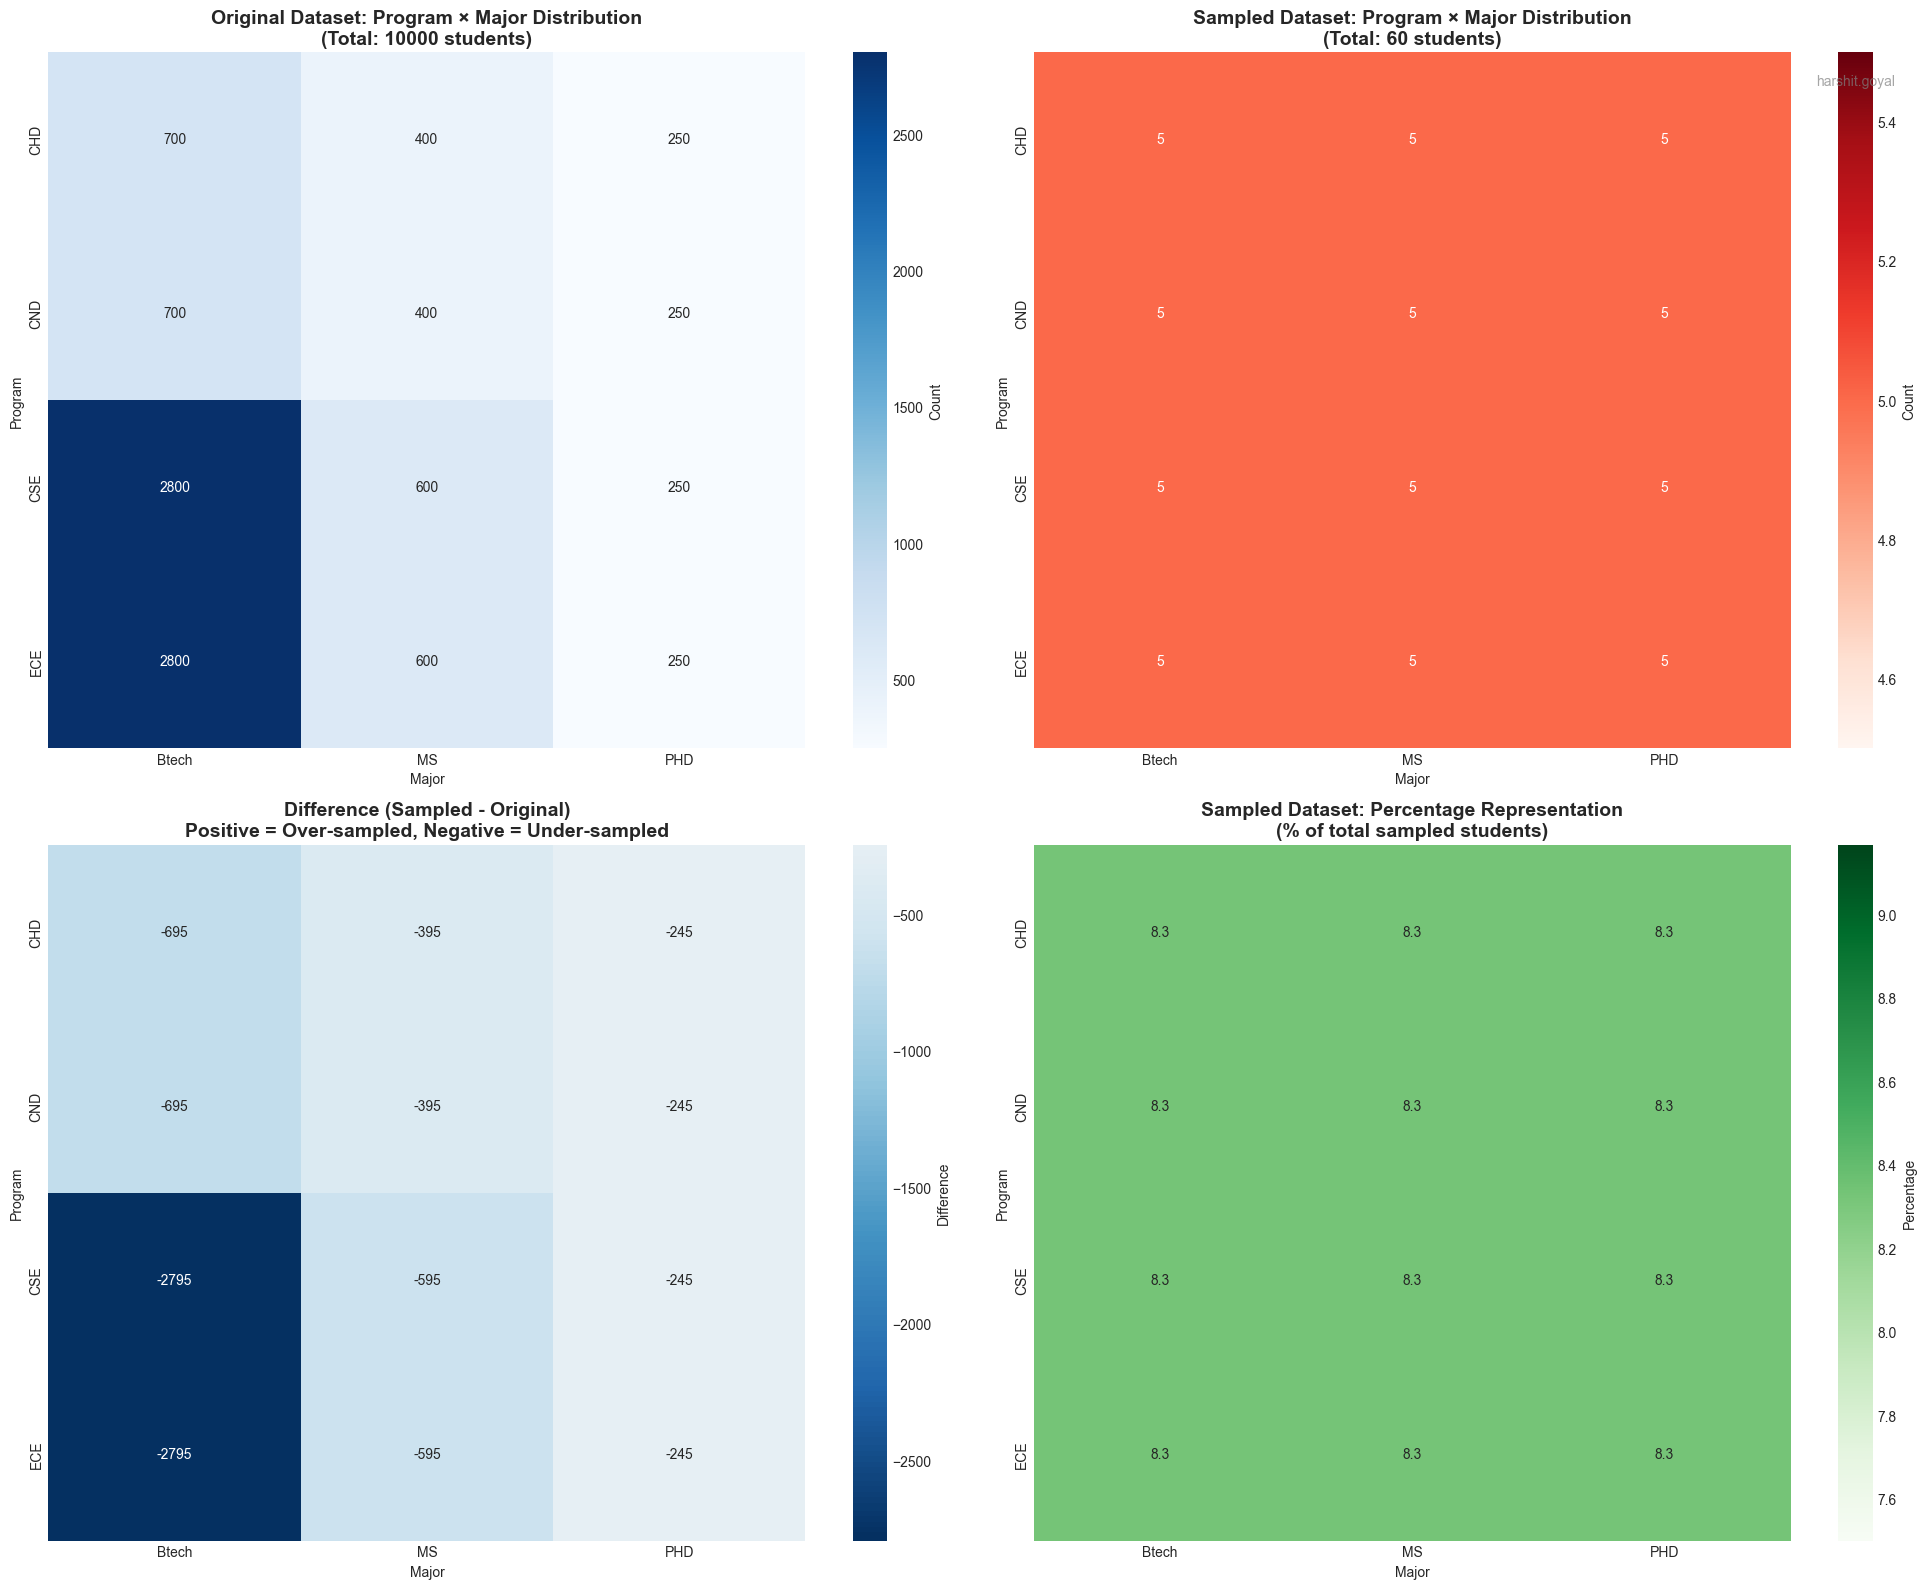


--------------------------------------------------
BALANCE ANALYSIS
--------------------------------------------------
Target samples per combination: 5
Actual range: 5 - 5
Standard deviation: 0.00
Coefficient of variation: 0.0%
Uniformity score: 1.000 (1.0 = perfectly uniform)


In [11]:
class ProgramMajorSampler():
    """Class for sampling students in a balanced way across Program and Major."""
    def __init__(self,data):
        """
        Initialize the ProgramMajorSampler with the student data.
        """
        self.data = data

    def sample_program_major_balanced(self, n: int) -> pd.DataFrame:
        """
        Argument n: int
        Returns a DataFrame of students in a balanced way across Program and Major.
        """

        valid_combinations = self.data.groupby(['Program', 'Major']).size().reset_index(name='count')
        total_combinations = len(valid_combinations)
        
        print(f"Found {total_combinations} valid (Program, Major) combinations")
        print("\nOriginal distribution:")
        for _, row in valid_combinations.iterrows():
            print(f"  {row['Program']} + {row['Major']}: {row['count']} students")
        
        base_samples_per_combo = n // total_combinations
        extra_samples = n % total_combinations
        
        print(f"\nSampling Strategy:")
        print(f"  Target total samples: {n}")
        print(f"  Base samples per combination: {base_samples_per_combo}")
        print(f"  Extra samples to distribute: {extra_samples}")
        
        sampled_students = []
        small_groups = []
        replacement_used = []
        
        for i, (_, combo_row) in enumerate(valid_combinations.iterrows()):
            program = combo_row['Program']
            major = combo_row['Major']
            available_students = combo_row['count']
            
            target_samples = base_samples_per_combo
            if i < extra_samples:  # Distribute extra samples to first few combinations
                target_samples += 1
            
            combo_students = self.data[
                (self.data['Program'] == program) & 
                (self.data['Major'] == major)
            ]
            
            if available_students < target_samples:
                small_groups.append({'program': program,'major': major,'available': available_students,'needed': target_samples})
                sampled_combo = combo_students.sample(n=target_samples, replace=True, random_state=42)
                replacement_used.append(f"{program} + {major}")
                
                print(f"  {program} + {major}: Sampled {target_samples} from {available_students} (WITH replacement)")
            else:
                sampled_combo = combo_students.sample(n=target_samples, replace=False, random_state=42)

                print(f"  {program} + {major}: Sampled {target_samples} from {available_students} (WITHOUT replacement)")
            
            sampled_students.append(sampled_combo)
        
        result_df = pd.concat(sampled_students, ignore_index=True)
        
        if small_groups:
            print(f"\n  SMALL GROUPS IDENTIFIED ({len(small_groups)} combinations):")
            print("="*60)
            for group in small_groups:
                shortage = group['needed'] - group['available']
                print(f"  {group['program']} + {group['major']}:")
                print(f"    Available: {group['available']} students")
                print(f"    Needed: {group['needed']} students") 
                print(f"    Shortage: {shortage} (used replacement sampling)")
                print()
        else:
            print(f"\n All groups had sufficient students - no replacement needed")
        
        print(f"\nFinal Results:")
        print(f"  Total sampled: {len(result_df)} students")
        print(f"  Combinations with replacement: {len(replacement_used)}")
        if replacement_used:
            print(f"  Replacement used for: {', '.join(replacement_used)}")
        
        return result_df
    
    def show_program_major_counts_and_heatmap(self, sampled_df: pd.DataFrame) -> None:
        """
        Argument sampled_df: pd.DataFrame
        Show program-major counts and a heatmap.
        Returns a DataFrame of program-major counts and a heatmap.
        """

        original_counts = self.data.groupby(['Program', 'Major']).size().reset_index(name='Original_Count')
        sampled_counts = sampled_df.groupby(['Program', 'Major']).size().reset_index(name='Sampled_Count')
        
        comparison = pd.merge(original_counts, sampled_counts, on=['Program', 'Major'], how='outer')
        comparison = comparison.fillna(0)
        comparison['Sampled_Count'] = comparison['Sampled_Count'].astype(int)
        comparison['Difference'] = comparison['Sampled_Count'] - comparison['Original_Count']
        comparison['Percentage_Original'] = (comparison['Original_Count'] / len(self.data) * 100).round(2)
        comparison['Percentage_Sampled'] = (comparison['Sampled_Count'] / len(sampled_df) * 100).round(2)
        
        print("\n" + "="*80)
        print("DETAILED COMPARISON TABLE")
        print("="*80)
        print(f"{'Program':<15} {'Major':<15} {'Original':<8} {'Sampled':<8} {'Diff':<6} {'Orig%':<7} {'Samp%':<7}")
        print("-" * 80)
        
        for _, row in comparison.iterrows():
            print(f"{row['Program']:<15} {row['Major']:<15} {row['Original_Count']:<8.0f} {row['Sampled_Count']:<8} "
                  f"{row['Difference']:<6.0f} {row['Percentage_Original']:<7}% {row['Percentage_Sampled']:<7}%")

        original_pivot = self.data.pivot_table(index='Program', columns='Major', values='GPA', aggfunc='count', fill_value=0)
        sampled_pivot = sampled_df.pivot_table(index='Program', columns='Major', values='GPA', aggfunc='count', fill_value=0)
        
        all_programs = sorted(set(self.data['Program'].unique()) | set(sampled_df['Program'].unique()))
        all_majors = sorted(set(self.data['Major'].unique()) | set(sampled_df['Major'].unique()))
        
        original_pivot = original_pivot.reindex(index=all_programs, columns=all_majors, fill_value=0)
        sampled_pivot = sampled_pivot.reindex(index=all_programs, columns=all_majors, fill_value=0)
        
        fig, axes = plt.subplots(2, 2, figsize=(20, 16))
        add_watermark(fig)

        axs = axes.flatten()

        sns.heatmap(original_pivot, annot=True, fmt='d', cmap='Blues', 
                   ax=axs[0], cbar_kws={'label': 'Count'})
        axs[0].set_title(f'Original Dataset: Program × Major Distribution\n(Total: {len(self.data)} students)', 
                           fontsize=14, fontweight='bold')
        axs[0].set_xlabel('Major')
        axs[0].set_ylabel('Program')

        sns.heatmap(sampled_pivot, annot=True, fmt='d', cmap='Reds',
                   ax=axs[1], cbar_kws={'label': 'Count'})
        axs[1].set_title(f'Sampled Dataset: Program × Major Distribution\n(Total: {len(sampled_df)} students)',
                         fontsize=14, fontweight='bold')
        axs[1].set_xlabel('Major')
        axs[1].set_ylabel('Program')

        diff_pivot = sampled_pivot - original_pivot
        sns.heatmap(diff_pivot, annot=True, fmt='d', cmap='RdBu_r', center=0,
                   ax=axs[2], cbar_kws={'label': 'Difference'})
        axs[2].set_title('Difference (Sampled - Original)\nPositive = Over-sampled, Negative = Under-sampled', 
                           fontsize=14, fontweight='bold')
        axs[2].set_xlabel('Major')
        axs[2].set_ylabel('Program')

        percentage_pivot = (sampled_pivot / len(sampled_df) * 100)
        sns.heatmap(percentage_pivot, annot=True, fmt='.1f', cmap='Greens',
                   ax=axs[3], cbar_kws={'label': 'Percentage'})
        axs[3].set_title('Sampled Dataset: Percentage Representation\n(% of total sampled students)',
                         fontsize=14, fontweight='bold')
        axs[3].set_xlabel('Major')
        axs[3].set_ylabel('Program')

        plt.tight_layout()
        plt.show()
        
        print("\n" + "-"*50)
        print("BALANCE ANALYSIS")
        print("-"*50)
        
        sampled_combo_counts = sampled_df.groupby(['Program', 'Major']).size()
        
        print(f"Target samples per combination: {len(sampled_df) // len(sampled_combo_counts)}")
        print(f"Actual range: {sampled_combo_counts.min()} - {sampled_combo_counts.max()}")
        print(f"Standard deviation: {sampled_combo_counts.std():.2f}")
        print(f"Coefficient of variation: {(sampled_combo_counts.std()/sampled_combo_counts.mean()*100):.1f}%")
        
        expected_per_combo = len(sampled_df) / len(sampled_combo_counts)
        uniformity_score = 1 - (sampled_combo_counts.std() / expected_per_combo)
        print(f"Uniformity score: {uniformity_score:.3f} (1.0 = perfectly uniform)")


sampler = ProgramMajorSampler(data)
sampled_students = sampler.sample_program_major_balanced(n=60)
sampler.show_program_major_counts_and_heatmap(sampled_students)

# When a (Program, Major) combination has fewer students than the target allocation:
# Automatically detects comb with fewer students, and then uses sampling WITH replacement for those groups,
# after which it indicated the groups requiring replacement

# This approach ensures:
#  All combinations are represented in the sample Distribution remains as balanced as possible
#  Total sample size (60) is maintained Transparency about sampling limitations

# The heatmaps will show:
# Original distribution patterns
# How sampling achieved better balance
# Where over/under-sampling occurred